In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

import intake

import sys
sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 

import metpy

import meteo

In [2]:
%load_ext autoreload
%autoreload 2

Diregarding intra-seasonal advection, the mean moisture profile is simply set by th balance between boundary layer top and surface fluxes.
$$ q_\mathrm{bl} = \frac{V_\mathrm{sfc} q_\mathrm{sfc} + E q_{h^+}}{V_\mathrm{sfc} + E}$$

here $V_\mathrm{sfc}$ and $E$ must have dimensions of mass fluxes ($\rho C\cdot U$, with units $g~m^{-2}~s^{-1}$)

then at the surface

$$ W_\mathrm{sfc} \approx \frac{q_\mathrm{bl}}{q_\mathrm{sfc}}  = \frac{V_\mathrm{sfc} + E \frac{q_{h^+}}{q_\mathrm{sfc}} }{V_\mathrm{sfc} + E} = \frac{V_\mathrm{sfc} + \chi \cdot E}{V_\mathrm{sfc} + E} $$

from this, I can rearrange the terms to estimate values for the vertical mass transport needed to attain such surface relative humidity $W_\mathrm{sfc}$

$$ E = \frac{\left( 1 - W_\mathrm{sfc} \right) \cdot V_\mathrm{sfc}}{W - \chi} $$

From the radiosoundings, $W_\mathrm{sfc} = 0.75$ .

Far reaching idea: use computed $E$ in bulk equation from $\theta$


In [4]:
min_hgt = 40.

level2_path = "/work/mh1498/m301248/TCO_data/eurec4a_profiles_level2/EUREC4A_BCO_Vaisala-RS_L2_v3.0.0.nc"
ds_eureca = xr.open_dataset(level2_path)
ds_eureca_bco = ds_eureca.where(((ds_eureca["platform"] == 1)&(ds_eureca["ascent_flag"]==1)&(ds_eureca.alt>min_hgt)), drop=True)
## renaming for common ground
ds_eureca_bco = ds_eureca_bco.swap_dims({"sounding": "launch_time"})
ds_eureca_bco = ds_eureca_bco.rename({"alt":"height"})


ds_orcestra = xr.open_dataset("ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4", engine="zarr")
ds_orcestra
ds_orcestra_bco = ds_orcestra.where(((ds_orcestra["platform"] == "BCO")&(ds_orcestra["ascent_flag"]==0)&(ds_orcestra.height>min_hgt)), drop=True)


In [5]:
## campaign-mean profiles
rh_eu = ds_eureca_bco.rh.mean(dim="launch_time")
wind_eu = ds_eureca_bco.wspd.mean(dim="launch_time")
temp_eu = ds_eureca_bco.ta.mean(dim="launch_time")
q_eu = ds_eureca_bco.q.mean(dim="launch_time")
press_eu = ds_eureca_bco.p.mean(dim="launch_time")


rh_or = ds_orcestra_bco.rh.mean(dim="launch_time")
wind_or = ds_orcestra_bco.wspd.mean(dim="launch_time")
temp_or = ds_orcestra_bco.ta.mean(dim="launch_time")
q_or = ds_orcestra_bco.q.mean(dim="launch_time")
press_or = ds_orcestra_bco.p.mean(dim="launch_time")


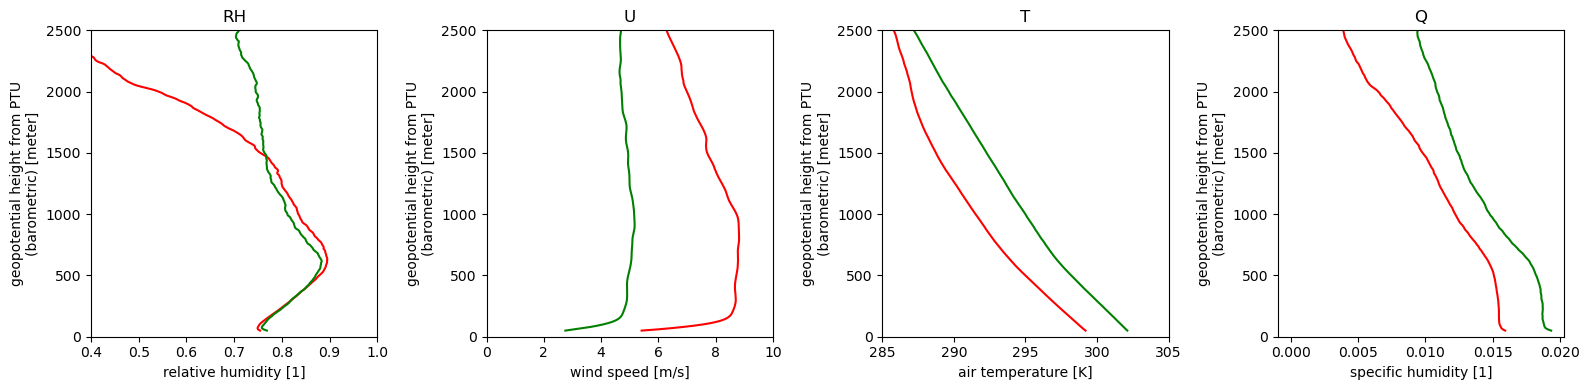

In [7]:
fig, ax = plt.subplots(1,4, figsize=(16,4))

rh_eu.plot.line(ax=ax[0], y="height", color="red")
rh_or.plot.line(ax=ax[0], y="height", color="green")
ax[0].set_title("RH")
ax[0].set_xlim(0.4, 1)

wind_eu.plot.line(ax=ax[1], y="height", color="red")
wind_or.plot.line(ax=ax[1], y="height", color="green")
ax[1].set_title("U")
ax[1].set_xlim(0, 10)


temp_eu.plot.line(ax=ax[2], y="height", color="red")
temp_or.plot.line(ax=ax[2], y="height", color="green")
ax[2].set_title("T")
ax[2].set_xlim(285, 305)


q_eu.plot.line(ax=ax[3], y="height", color="red")
q_or.plot.line(ax=ax[3], y="height", color="green")
ax[3].set_title("Q")
# ax[2].set_xlim(285, 305)



for x in ax:
    x.set_ylim(0,2.5e3)


plt.tight_layout()


In [6]:
## load campaign-mean SST data
ingr_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/EUREC4A_IngrFlux.nc")
sst_eu = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

ingr_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/ORCESTRA_IngrFlux.nc")
sst_or = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

In [7]:
## compute mean q_sfc
from meteo import qsea

sst_local = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33])
q_sfc_eu = qsea(sst_local-273.15, 1013.)
q_sfc_eu = np.mean(q_sfc_eu)

sst_local = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33])
q_sfc_or = qsea(sst_local-273.15, 1013.)
q_sfc_or = np.mean(q_sfc_or)

#### check what kind of radiative heating (cooling) rates we get with 3h data

In [8]:
cat = intake.open_catalog("https://tcodata.mpimet.mpg.de/catalog.yaml")
ds_rad = cat.BCO.radiation_c2.to_dask()

/work/mh1498/m301248/conda/envs/env_hacka/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [10]:
ds_rad

<xarray.Dataset> Size: 2GB
Dimensions:       (time: 27805510)
Coordinates:
  * time          (time) datetime64[ns] 222MB 2015-10-15 ... 2016-10-11T23:59:59
    alt           float64 8B ...
    lat           float64 8B ...
    lon           float64 8B ...
Data variables: (12/17)
    LWD_diff      (time) float32 111MB dask.array<chunksize=(262144,), meta=np.ndarray>
    LWD_diff_S    (time) float32 111MB dask.array<chunksize=(262144,), meta=np.ndarray>
    LWD_diff_T    (time) float32 111MB dask.array<chunksize=(262144,), meta=np.ndarray>
    LWD_diff_V    (time) float32 111MB dask.array<chunksize=(262144,), meta=np.ndarray>
    SWD_diff      (time) float32 111MB dask.array<chunksize=(262144,), meta=np.ndarray>
    SWD_diff_S    (time) float32 111MB dask.array<chunksize=(262144,), meta=np.ndarray>
    ...            ...
    SWD_dir_V     (time) float32 111MB dask.array<chunksize=(262144,), meta=np.ndarray>
    SWD_global    (time) float32 111MB dask.array<chunksize=(262144,), meta=np.ndarray>
    SWD_global_S  (time) float32 111MB dask.array<chunksize=(262144,), meta=np.ndarray>
    SWD_global_T  (time) float32 111MB dask.array<chunksize=(262144,), meta=np.ndarray>
    SWD_global_V  (time) float32 111MB dask.array<chunksize=(262144,), meta=np.ndarray>
    sensor_set    (time) uint16 56MB dask.array<chunksize=(262144,), meta=np.ndarray>
Attributes:
    Conventions:           CF-1.12
    _logical_cutoff_date:  2016-10-12T00:00:00Z
    bcoproc_version:       0.0.0.post1185.dev0+c830e01
    featureType:           timeSeries
    institution:           Max Planck Institute for Meteorology, Hamburg
    license:               CC0-1.0
    location:              The Barbados Cloud Observatory (BCO), Deebles Poin...
    platform:              BCO
    source:                Kipp & Zonen CMP21 (shaded and un-shaded) pyranome...
    summary:               This dataset contains measurements of downwelling ...
    title:                 Radiation data from BCO (Level 1)
    tool_versions:         {"Python": "3.11.2 (main, Apr 28 2025, 14:11:48) [...

In [9]:
# time_eu = slice("2020-01-01", "2020-02-28")
# time_or = slice("2024-08-01", "2024-10-01")

start, end = ds_eureca_bco.launch_time[0] - pd.Timedelta("2h"), ds_eureca_bco.launch_time[-1] + pd.Timedelta("2h")
rad = ds_rad.sel(time=slice(start,end))


dt = pd.Timedelta("30min")

time = rad.time
launch = ds_eureca_bco.launch_time

mask = (abs(time - launch) <= dt)    ## select ceilometer data, 60 minutes windows centred on launch_time
rad_windowed = rad.expand_dims(launch_time=launch).where(mask)


rad_windowed

NameError: name 'ds_eureca_bco' is not defined

In [ ]:
lw_win_mean = rad_windowed.LWD_diff.mean(dim="time")
sw_win_mean = rad_windowed.SWD_dir.mean(dim="time")



<xarray.DataArray 'SWD_dir' (launch_time: 182)> Size: 728B
dask.array<mean_agg-aggregate, shape=(182,), dtype=float32, chunksize=(182,), chunktype=numpy.ndarray>
Coordinates:
  * launch_time  (launch_time) datetime64[ns] 1kB 2020-01-16T20:53:46 ... 202...
    sounding     (launch_time) <U40 29kB 'BCO__ascent__13.16_-59.43__20200116...
    alt          float64 8B ...
    lat          float64 8B ...
    lon          float64 8B ...
Attributes:
    long_name:      Shortwave downwelling direct radiation
    standard_name:  surface_direct_downwelling_shortwave_flux_in_air
    units:          W m-2

In [13]:
sw_win_mean.values

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

In [ ]:

nan_mask = (sw_win_mean.notnull())  &  (lw_win_mean.notnull())


lw_win_mean = lw_win_mean.where(nan_mask, drop=False)#.dropna(dim="launch_time")
sw_win_mean = sw_win_mean.where(nan_mask, drop=False).clip(min=0) #.dropna(dim="launch_time")


lw_win_mean.plot.line(x="launch_time")
sw_win_mean.plot.line(x="launch_time")

In [10]:
## what is the reference layer to compute mixed layer AVERAGED quantities?
mixed_avg_levels   = slice(200, 500)

theta_bl = ds_eureca_bco.theta.sel(height=mixed_avg_levels).mean().values

In [11]:
sst = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"])


# Step 1: Extract date from sw_win_mean time
sw_dates = sw_win_mean.launch_time.dt.date

# Step 2: Create a dictionary: date → sst value
date_to_sst = dict(zip(sst.time.dt.date.values, sst.values))

# Step 3: Use apply_ufunc to map each sw_win_mean time to its daily sst
sst_aligned = xr.apply_ufunc(
    lambda date: date_to_sst[date],
    sw_win_mean.launch_time.dt.date,
    input_core_dims=[[]],
    output_core_dims=[[]],
    vectorize=True,
    dask='allowed'
)


In [12]:
eps = 0.39           ## Following Zheng 2019, with \mu = 0.1 and q = 1e-2 kg/kg , I would get about -4 K/day
oc_abs = 0.97        ## ocean absorptivity == emissivity
stefan = 5.67*1e-8
eta = 0.02
oc_alb = 0.055

def rad_terms(sw_in, lw_in, sst):
    return (eps/(1-eps))*lw_in +eps*oc_abs*stefan*(sst)**4 + ((eta/(1-eta)) + eta*(1-oc_alb))*sw_in

def R_net(sw_in, lw_in, sst, theta_bl):
    return rad_terms(sw_in, lw_in, sst) - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl)**4

# non_thBL_terms_eu = rad_terms(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values, ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values, sst_eu.values)
# non_thBL_terms_or = rad_terms(ingr_or.sw_global.sel(cell=0).mean(dim="time").values, ingr_or.lw_diff.sel(cell=0).mean(dim="time").values, sst_or.values)

RNet_eu = R_net(sw_win_mean,
                lw_win_mean,
                sst_aligned, 
                theta_bl)

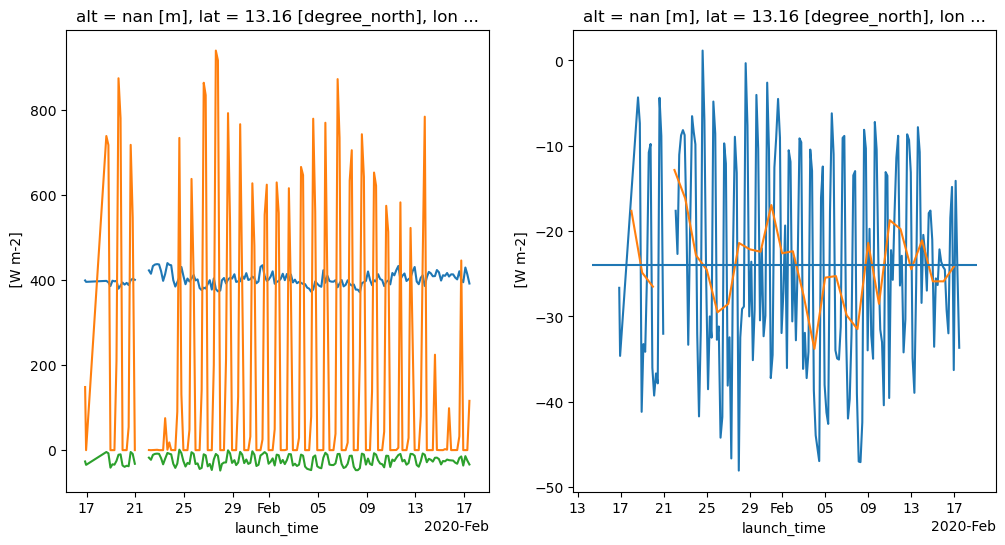

In [13]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))


lw_win_mean.plot.line(ax=ax[0], x="launch_time")
sw_win_mean.plot.line(ax=ax[0], x="launch_time")

# ax[0].plot(lw_win_mean.launch_time.values, RNet_eu)
RNet_eu.plot.line(ax=ax[0], x="launch_time")

# ax[1].plot(lw_win_mean.launch_time.values, RNet_eu)
RNet_eu.plot.line(ax=ax[1], x="launch_time")
RNet_eu.resample(launch_time="1d").mean().plot.line(ax=ax[1], x="launch_time")
ax[1].hlines(y=RNet_eu.mean(dim="launch_time").values, xmin=ax[1].get_xlim()[0], xmax=ax[1].get_xlim()[1])

#### do U and q_sfc or fluxes compensate ?

In [10]:
fluxes_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/sfcFluxes_EUREC4A.nc")
lhf_era5_eu = fluxes_eu.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
shf_era5_eu = fluxes_eu.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

fuxes_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/sfcFluxes_ORCESTRA.nc")
lhf_era5_or = fuxes_or.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
shf_era5_or = fuxes_or.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

In [11]:
print(f"Uq EU = {(wind_eu.isel(height=0)*q_sfc_eu):.2f} ; Uq OR = {(wind_or.isel(height=0)*q_sfc_or):.2f}")
print(f"LHF ERA5 EU = {lhf_era5_eu.values:.2f}  ;  LHF ERA5 EU = {lhf_era5_or.values:.2f}")
print("check how the drag coefficients change!")

Uq EU = 119.22 ; Uq OR = 71.95
LHF ERA5 EU = 171.35  ;  LHF ERA5 EU = 134.73
check how the drag coefficients change!


In [12]:
import coare35vn

## ATTENTION: here output only [hsb,hlb, rhoa, Ch,Ce]

u = wind_eu.isel(height=0)
t = temp_eu.isel(height=0)
rh = rh_eu.isel(height=0)
ts = sst_eu
P = 1013.
Rs = ingr_eu.sw_global.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
Rl = ingr_eu.lw_diff.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

output_eu = coare35vn.coare35vn(u=u.values,
                             t=t.values-273.15,
                             rh=100*rh.values,
                             ts=ts.values-273.15,
                             P=P,
                             Rs=Rs.values,
                             Rl=Rl.values, 
                             zu=50, zt=50, zq=50, lat=13, zi=600, rain=None, cp=None, sigH=None, jcool=1)




u = wind_or.isel(height=0)
t = temp_or.isel(height=0)
rh = rh_or.isel(height=0)
ts = sst_or
P = 1013.
Rs = ingr_or.sw_global.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
Rl = ingr_or.lw_diff.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

output_or = coare35vn.coare35vn(u=u.values,
                             t=t.values-273.15,
                             rh=100*rh.values,
                             ts=ts.values-273.15,
                             P=P,
                             Rs=Rs.values,
                             Rl=Rl.values, 
                             zu=50, zt=50, zq=50, lat=13, zi=600, rain=None, cp=None, sigH=None, jcool=1)


/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/meteo.py:156: RuntimeWarning: invalid value encountered in power
  psi = -((1 + 0.6667*zet)**1.5 + 0.6667*(zet - 14.28)*exp(-dzet) + 8.525)


In [13]:
rho_eu, Ch_eu, Ce_eu = output_eu[0,2], output_eu[0,3] , output_eu[0,4]
rho_or, Ch_or, Ce_or = output_or[0,2], output_or[0,3] , output_or[0,4]

lhf_eu_rec, lhf_or_rec = output_eu[0,1], output_or[0,1]
shf_eu_rec, shf_or_rec = output_eu[0,0], output_or[0,0]

In [14]:
print(f"Uq EU = {(wind_eu.isel(height=0)*q_sfc_eu):.2f} ; Uq OR = {(wind_or.isel(height=0)*q_sfc_or):.2f}")
print(f"rho Ce Uq EU = {(rho_eu*Ce_eu*wind_eu.isel(height=0)*q_sfc_eu):.2f} ; rho Ce Uq OR = {(rho_or*Ce_or*wind_or.isel(height=0)*q_sfc_or):.2f}")

print(f"Ce EU = {(Ce_eu):.5f} ; Ce OR = {(Ce_or):.5f}")


print(f"LHF ERA5 EU = {lhf_era5_eu.values:.2f}  ;  LHF ERA5 EU = {lhf_era5_or.values:.2f}")
print(f"LHF EU from prof = {lhf_eu_rec:.2f}  ;  LHF ERA5 EU = {lhf_or_rec:.2f}")


Uq EU = 119.22 ; Uq OR = 71.95
rho Ce Uq EU = 0.16 ; rho Ce Uq OR = 0.11
Ce EU = 0.00113 ; Ce OR = 0.00134
LHF ERA5 EU = 171.35  ;  LHF ERA5 EU = 134.73
LHF EU from prof = 102.70  ;  LHF ERA5 EU = 69.45


In [15]:
import pandas as pd
from IPython.display import display, HTML

data = [
    [r"Uq (m/s g/kg)", f"{(wind_eu.isel(height=0) * q_sfc_eu):.2f}", f"{(wind_or.isel(height=0) * q_sfc_or):.2f}"],
    ["ρCeUq (g / m²s)", f"{(rho_eu * Ce_eu * wind_eu.isel(height=0) * q_sfc_eu):.2f}", f"{(rho_or * Ce_or * wind_or.isel(height=0) * q_sfc_or):.2f}"],
    ["Ce", f"{Ce_eu:.5f}", f"{Ce_or:.5f}"],
    ["Ch", f"{Ch_eu:.5f}", f"{Ch_or:.5f}"],
    ["LHF ERA5 (W/m²)", f"{lhf_era5_eu:.2f}", f"{lhf_era5_or:.2f}"],
    ["LHF from Prof (50m) (W/m²)", f"{lhf_eu_rec:.2f}", f"{lhf_or_rec:.2f}"],
]

# Create DataFrame
df = pd.DataFrame(data, columns=["Quantity", "EU", "OR"])

display(HTML(df.to_html(index=False, table_id="summary-table")))

Quantity,EU,OR
Uq (m/s g/kg),119.22,71.95
ρCeUq (g / m²s),0.16,0.11
Ce,0.00113,0.00134
Ch,0.00113,0.00134
LHF ERA5 (W/m²),171.35,134.73
LHF from Prof (50m) (W/m²),102.70,69.45


## Merging the two with a local MSE budget

With my current nomenclature and Yokoi and Katsumata 2022:

$$V_{s,SHF} \cdot (SST - \theta_{BL}) + m_{E} \cdot (\theta_E - \theta_{BL}) + m_{cd} \cdot (\theta_{cd} - \theta_{BL}) + R/c_p = 0$$
$$V_{s,LHF} \cdot (q^*_{sfc} - q_{BL}) + m_{E} \cdot (q_E - q_{BL}) + m_{cd} \cdot (q^*_{cd} - q_{BL}) = 0$$


actually, I should use the ERA5 surface heat fluxes 

$$H/c_p + m_{E} \cdot (\theta_E - \theta_{BL}) + m_{cd} \cdot (\theta_{cd} - \theta_{BL}) + R/c_p = 0$$
$$LH/L_v + m_{E} \cdot (q_E - q_{BL}) + m_{cd} \cdot (q^*_{cd} - q_{BL}) = 0$$

In [16]:
entrainment_levels = slice(700, 800)

downdraft_levels_eu = slice(1000, 2000)
downdraft_levels_or = slice(2500, 3500)

In [ ]:
# ## load campaign-mean SST data
# ingr_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/EUREC4A_IngrFlux.nc")
# sst_eu = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

# ingr_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/ORCESTRA_IngrFlux.nc")
# sst_or = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])



# sst_local = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33])
# q_sfc_eu = meteo.qsea(sst_local-273.15, 1013.)
# q_sfc_eu = np.mean(q_sfc_eu)

# sst_local = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33])
# q_sfc_or = meteo.qsea(sst_local-273.15, 1013.)
# q_sfc_or = np.mean(q_sfc_or)

In [ ]:
# fluxes_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/sfcFluxes_EUREC4A.nc")
# lhf_era5_eu = fluxes_eu.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
# shf_era5_eu = fluxes_eu.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

# fuxes_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/sfcFluxes_ORCESTRA.nc")
# lhf_era5_or = fuxes_or.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
# shf_era5_or = fuxes_or.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

In [17]:
## compute thetaD
from scipy.optimize import root_scalar

def temp_from_h(theta, p, h_cd, Lv, cp):
    es = 6.1121 * np.exp(17.502 * (theta-273.15) / (240.97 + (theta-273.15)))
    denominator = p - 0.378 * es * (1.0007 + p * 3.46e-6)
    
    return h_cd/cp - theta - (Lv / cp) * 0.622 * es * (1.0007 + p * 3.46e-6) / denominator


def find_theta_for_pair(p, h):
    # def f(t):
    #     return temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp)
    
    f = lambda t : temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp)

    try:
        sol = root_scalar(f, bracket=[285,295], method='brentq')
        return sol.root if sol.converged else np.nan
    except Exception as e:
        print(f"Exception for p={p:.2f}, h={h:.2f}: {e}")
        return np.nan




In [18]:
## data to use
h_cd_eu = (cp*ds_eureca_bco["ta"] + Lv*ds_eureca_bco["mr"] + g*ds_eureca_bco.height).mean(dim="launch_time").sel(height=downdraft_levels_eu)
h_cd_or = (cp*ds_orcestra_bco["ta"] + Lv*ds_orcestra_bco["mr"] + g*ds_orcestra_bco.height).mean(dim="launch_time").sel(height=downdraft_levels_or)

p_cd_eu = ds_eureca_bco["p"].mean(dim="launch_time").sel(height=downdraft_levels_eu).values
p_cd_or = ds_orcestra_bco["p"].mean(dim="launch_time").sel(height=downdraft_levels_or).values

## sfc_pressure
sfc_pressure_eu = 1e5*np.ones_like(p_cd_eu)    # Pa
sfc_pressure_or = 1e5*np.ones_like(p_cd_or)    # Pa

# since I am working with arrays
vectorized_theta_root = np.vectorize(find_theta_for_pair)

# Apply to arrays
thetaD_eu = vectorized_theta_root( sfc_pressure_eu / 100., h_cd_eu)
thetaD_or = vectorized_theta_root( sfc_pressure_or / 100., h_cd_or)




from metpy.units import units
ref_p = metpy.calc.height_to_pressure_std(600*units.m)
ref_p = ref_p.to(units.hPa).magnitude

# compute corresponding saturation humidity in the BL
qSat_out_eu = meteo.qsea(  thetaD_eu-273.15 , sfc_pressure_eu/100.  )/1e3    # kg / kg   # p_cd_eu/100
qSat_out_or = meteo.qsea(  thetaD_or-273.15 , sfc_pressure_or/100.  )/1e3    # kg / kg   # p_cd_or/100

In [19]:
## all theta data
theta_eu = ds_eureca_bco.theta.mean(dim="launch_time")
theta_or = ds_orcestra_bco.theta.mean(dim="launch_time")

'''thetaD_out_eu = theta_eu.isel(height=downdraft_levels_idx_eu).mean(dim="height").values
thetaD_out_or = theta_or.isel(height=downdraft_levels_idx_or).mean(dim="height").values'''

theta_out_eu = theta_eu.sel(height=entrainment_levels).values
theta_out_or = theta_or.sel(height=entrainment_levels).values

theta_bl_eu = theta_eu.sel(height=mixed_avg_levels).mean().values
theta_bl_or = theta_or.sel(height=mixed_avg_levels).mean().values


## all humidity data
q_eu = ds_eureca_bco.q.mean(dim="launch_time")
q_or = ds_orcestra_bco.q.mean(dim="launch_time")

'''qSat_out_eu = ((q_eu.isel(height=downdraft_levels_idx_eu).values)/rh_eu.isel(height=downdraft_levels_idx_eu)).mean(dim="height").values
qSat_out_or = ((q_or.isel(height=downdraft_levels_idx_or).values)/rh_or.isel(height=downdraft_levels_idx_or)).mean(dim="height").values'''

q_out_eu = q_eu.sel(height=entrainment_levels).values
q_out_or = q_or.sel(height=entrainment_levels).values

q_bl_eu = q_eu.sel(height=mixed_avg_levels).mean().values
q_bl_or = q_or.sel(height=mixed_avg_levels).mean().values


In [ ]:
eps = 0.14           ## Following Zheng 2019, with \mu = 0.1 and q = 1e-2 kg/kg , I would get about -4 K/day
oc_abs = 0.97        ## ocean absorptivity == emissivity
stefan = 5.67*1e-8
eta = 0.02
oc_alb = 0.055

def rad_terms(sw_in, lw_in, sst):
    return (eps/(1-eps))*lw_in +eps*oc_abs*stefan*(sst)**4 + ((eta/(1-eta)) + eta*(1-oc_alb))*sw_in

def R_net(sw_in, lw_in, sst, theta_bl):
    return rad_terms(sw_in, lw_in, sst) - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl)**4

# non_thBL_terms_eu = rad_terms(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values, ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values, sst_eu.values)
# non_thBL_terms_or = rad_terms(ingr_or.sw_global.sel(cell=0).mean(dim="time").values, ingr_or.lw_diff.sel(cell=0).mean(dim="time").values, sst_or.values)

RNet_eu = R_net(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values,
                ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values,
                sst_eu.values, 
                theta_bl_eu)
RNet_or = R_net(ingr_or.sw_global.sel(cell=0).mean(dim="time").values,
                ingr_or.lw_diff.sel(cell=0).mean(dim="time").values,
                sst_or.values, 
                theta_bl_or)

In [36]:

RNet_time = R_net(ingr_eu.sw_global.sel(cell=0).values,
                ingr_eu.lw_diff.sel(cell=0).values,
                ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).values, 
                ds_eureca_bco.theta.sel(height=mixed_avg_levels).mean().values)

RNet_time

array([ -5.2170217 ,  -5.35728022,  -5.26533173,  -5.22966164,
        -5.27552886,  -5.43850709,  -5.52257197,  -5.60348086,
        -5.76168628,  -5.71404458,  -5.88134312,  -5.932878  ,
       -13.22550612,  -9.12416404,  -9.2752493 ,  -9.42569162,
       -13.20353326, -14.36294859, -16.71607   , -14.30967259,
        -6.3838081 ,  -5.94182682,  -7.1522741 ,  -9.65707555,
       -13.67974661, -16.66290163, -18.56396356, -12.90284547,
       -10.73251054, -11.51032054,  -8.75901388, -10.3644106 ,
       -11.40950295, -15.49051326, -18.68222104, -13.53235931,
       -13.43298142, -12.67210362, -17.53657142, -11.40488756,
       -13.26450013,  -7.71281944,  -7.64940967, -12.37440299,
       -10.4891227 , -13.07300919, -12.37126496,  -8.79011289,
        -5.46249462,  -5.12144496, -15.56278508, -14.58088007,
       -15.73504369,  -7.83677603,  -9.74165729, -11.82915948,
        -9.82093744, -13.65993716, -13.3863132 ])

In [119]:
############  matrix coefficients
cp = 1004. 
Lv = 2.5e6

## save resulting values, depending on height selected
me_eu, me_or = [], []
mD_eu, mD_or = [], []


##
 
for i in range(theta_out_eu.size): # theta_out_eu.shape
    A_eu = np.array([
        [
            theta_out_eu[i] - theta_bl_eu,  np.nanmean(thetaD_eu) - theta_bl_eu
        ],
        [
            q_out_eu[i] - q_bl_eu,          np.nanmean(qSat_out_eu) - q_bl_eu
        ]
    ])

    b_eu = np.array([
        - shf_era5_eu/cp - (-6.)/cp,   #(non_thBL_terms_eu - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_eu)**4)/cp ,
        - lhf_era5_eu / Lv
    ])

    ## shf and lhf _rec are the ones obtained from radiosoundings applied to COARE routines

    # b_eu = np.array([
    #     - shf_eu_rec / cp - (non_thBL_terms_eu - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_eu.values)**4)/cp ,
    #     - lhf_eu_rec / Lv
    # ])
    
    x_eu = np.linalg.pinv(A_eu) @ b_eu

    me_eu.append(x_eu[0])
    mD_eu.append(x_eu[1])


for i in range(theta_out_or.size):
    A_or = np.array([
        [
            theta_out_or[i] - theta_bl_or,    np.nanmean(thetaD_or) - theta_bl_or
        ],
        [
            q_out_or[i] - q_bl_or,            np.nanmean(qSat_out_or) - q_bl_or
        ]
    ])

    b_or = np.array([
        - shf_era5_or/cp - (-6.)/cp,    #( non_thBL_terms_or - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_or)**4 )/cp,
        - lhf_era5_or/Lv 
    ])

    ## shf and lhf _rec are the ones obtained from radiosoundings applied to COARE routines

    # b_or = np.array([
    #     - shf_or_rec/cp - ( non_thBL_terms_or - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_or)**4 )/cp,
    #     - lhf_or_rec/Lv 
    # ])

    

    x_or = np.linalg.pinv(A_or) @ b_or

    me_or.append(x_or[0])
    mD_or.append(x_or[1])

me_eu, me_or = np.array(me_eu), np.array(me_or)
mD_eu, mD_or = np.array(mD_eu), np.array(mD_or)


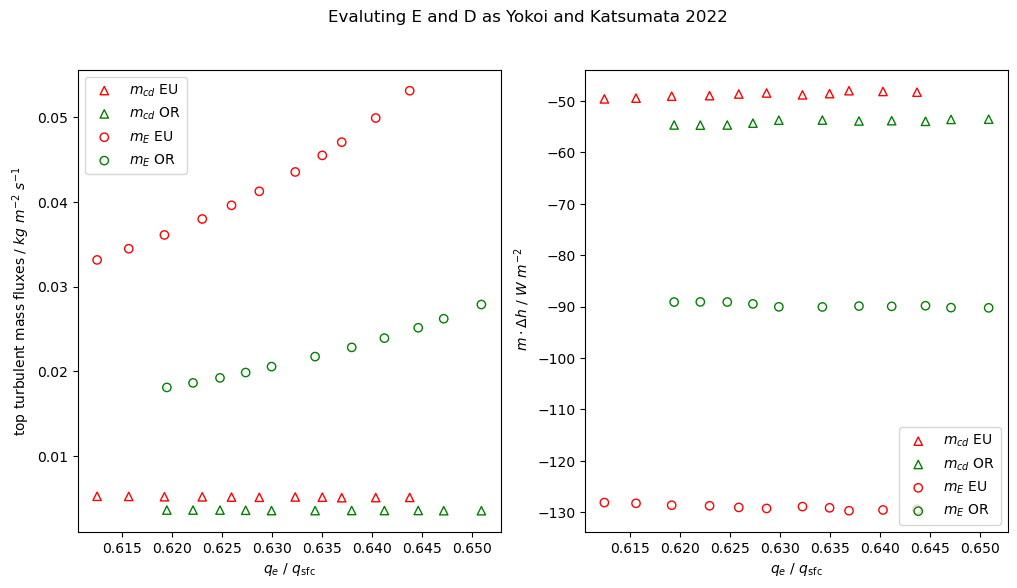

In [120]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Evaluting E and D as Yokoi and Katsumata 2022")

#### report E for values of q_out
ax[0].scatter(q_out_eu*1e3/q_sfc_eu, mD_eu, marker="^", facecolors='none', edgecolors="red", label=r"$m_{cd}$ EU")
ax[0].scatter(q_out_or*1e3/q_sfc_or, mD_or, marker="^", facecolors='none', edgecolors="green", label=r"$m_{cd}$ OR")

ax[0].scatter(q_out_eu*1e3/q_sfc_eu, me_eu, marker="o", facecolors='none', edgecolors="red", label=r"$m_{E}$ EU")
ax[0].scatter(q_out_or*1e3/q_sfc_or, me_or, marker="o", facecolors='none', edgecolors="green", label=r"$m_{E}$ OR")

ax[0].set_xlabel(r"$q_e$ / $q_\mathrm{sfc}$")
ax[0].set_ylabel(r"top turbulent mass fluxes / $kg~m^{-2}~s^{-1}$")
ax[0].legend()




#### report E for values of q_out
ax[1].scatter(q_out_eu*1e3/q_sfc_eu, mD_eu*(  cp*(np.nanmean(thetaD_eu) - theta_bl_eu) + Lv*(np.nanmean(qSat_out_eu) - q_bl_eu)  ), marker="^", facecolors='none', edgecolors="red", label=r"$m_{cd}$ EU")
ax[1].scatter(q_out_or*1e3/q_sfc_or, mD_or*(  cp*(np.nanmean(thetaD_or) - theta_bl_or) + Lv*(np.nanmean(qSat_out_or) - q_bl_or)  ), marker="^", facecolors='none', edgecolors="green", label=r"$m_{cd}$ OR")

ax[1].scatter(q_out_eu*1e3/q_sfc_eu, me_eu*( cp*(theta_out_eu - theta_bl_eu) + Lv*(q_out_eu - q_bl_eu) ) , marker="o", facecolors='none', edgecolors="red", label=r"$m_{E}$ EU")
ax[1].scatter(q_out_or*1e3/q_sfc_or, me_or*( cp*(theta_out_or - theta_bl_or) + Lv*(q_out_or - q_bl_or) ), marker="o", facecolors='none', edgecolors="green", label=r"$m_{E}$ OR")
ax[1].set_xlabel(r"$q_e$ / $q_\mathrm{sfc}$")
ax[1].set_ylabel(r" $m\cdot \Delta h$ / $W~m^{-2}$")
ax[1].legend()


In [63]:
import pandas as pd
from IPython.display import display, HTML

data = [
    ["LHF ERA5 (W/m²)", f"{lhf_era5_eu:.2f}", f"{lhf_era5_or:.2f}"],
    ["SHF ERA5 (W/m²)", f"{shf_era5_eu:.2f}", f"{shf_era5_or:.2f}"],
    ["R net (W/m²)", f"{( non_thBL_terms_eu - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_eu)**4 ):.2f}", f"{( non_thBL_terms_or - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_or)**4 ):.2f}"],
    [r"q_e - q_{BL} (g/kg)", f"{1e3*(q_out_eu[0] - q_bl_eu):.2f}", f"{1e3*(q_out_or[0] - q_bl_or):.2f}"],
    [r"q_cd - q_{BL} (g/kg)", f"{1e3*(qSat_out_eu[0] - q_bl_eu):.2f}", f"{1e3*(qSat_out_or[0] - q_bl_or):.2f}"],
    [r"$\theta_e$ - $\theta_{BL}$ (K)", f"{(theta_out_eu[0] - theta_bl_eu):.2f}", f"{(theta_out_or[0] - theta_bl_or):.2f}"],
    [r"$\theta_{cd}$ - $\theta_{BL}$ (K)", f"{(np.nanmean(thetaD_eu) - theta_bl_eu):.2f}", f"{(np.nanmean(thetaD_or) - theta_bl_or):.2f}"],
    
]

# Create DataFrame
df = pd.DataFrame(data, columns=["Quantity","EU", "OR"])

display(HTML(df.to_html(index=False, table_id="summary-table")))

Quantity,EU,OR
LHF ERA5 (W/m²),171.35,134.73
SHF ERA5 (W/m²),12.37,15.08
R net (W/m²),1.43,2.76
q_e - q_{BL} (g/kg),-1.15,-1.54
q_cd - q_{BL} (g/kg),0.16,-1.36
$\theta_e$ - $\theta_{BL}$ (K),0.44,0.62
$\theta_{cd}$ - $\theta_{BL}$ (K),-7.60,-11.32


#### check radiation part!!

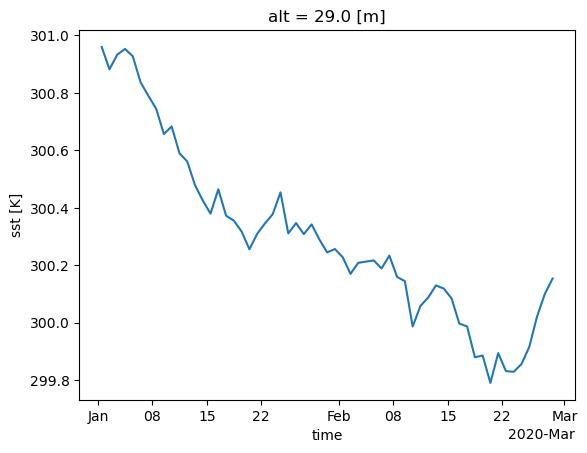

In [72]:
ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).plot.line()

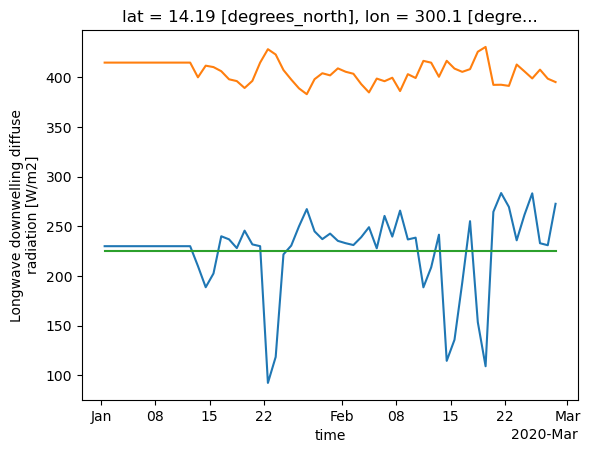

In [105]:
ingr_eu.sw_global.sel(cell=0).plot.line()
ingr_eu.lw_diff.sel(cell=0).plot.line()

mean_sw = ingr_eu.sw_global.sel(cell=0).mean(dim="time").values
mean_sw = mean_sw*np.ones(ingr_eu.time.size)

plt.plot(ingr_eu.time.values, mean_sw)


In [93]:
mean_sw = ingr_or.sw_global.sel(cell=0).mean(dim="time").values
mean_sw

array(255.77151, dtype=float32)

In [42]:
## see dependence also on choice of downdraft levels


## save resulting values, depending on height selected
me_eu, me_or = np.zeros((q_out_eu.size, qSat_out_eu.size)), np.zeros((q_out_eu.size, qSat_out_eu.size))
mD_eu, mD_or = np.zeros((q_out_or.size, qSat_out_or.size)), np.zeros((q_out_or.size, qSat_out_or.size))


##
 
for i in range(me_eu[:,0].size):
    for j in range(me_eu[0,:].size):
        A_eu = np.array([
            [
                theta_out_eu[i] - theta_bl_eu,  thetaD_eu[j] - theta_bl_eu
            ],
            [
                q_out_eu[i] - q_bl_eu,          qSat_out_eu[j] - q_bl_eu
            ]
        ])

        b_eu = np.array([
            - shf_era5_eu.values/cp - (non_thBL_terms_eu - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_eu.values)**4)/cp ,
            - lhf_era5_eu.values / Lv
        ])

        x_eu = np.linalg.pinv(A_eu) @ b_eu

        me_eu[i,j] = x_eu[0]
        mD_eu[i,j] = x_eu[1]


for i in range(me_or[:,0].size):
    for j in range(me_or[0,:].size):
        A_or = np.array([
            [
                theta_out_or[i] - theta_bl_or,    thetaD_or[j] - theta_bl_or
            ],
            [
                q_out_or[i] - q_bl_or,            qSat_out_or[j] - q_bl_or
            ]
        ])

        b_or = np.array([
            - shf_era5_or.values/cp - ( non_thBL_terms_or - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_or)**4 )/cp,
            - lhf_era5_or.values/Lv 
        ])

        x_or = np.linalg.pinv(A_or) @ b_or

        me_or[i,j] = x_or[0]
        mD_or[i,j] = x_or[1]

me_eu, me_or = np.array(me_eu), np.array(me_or)
mD_eu, mD_or = np.array(mD_eu), np.array(mD_or)


In [108]:
theta_out_eu.shape

(11,)

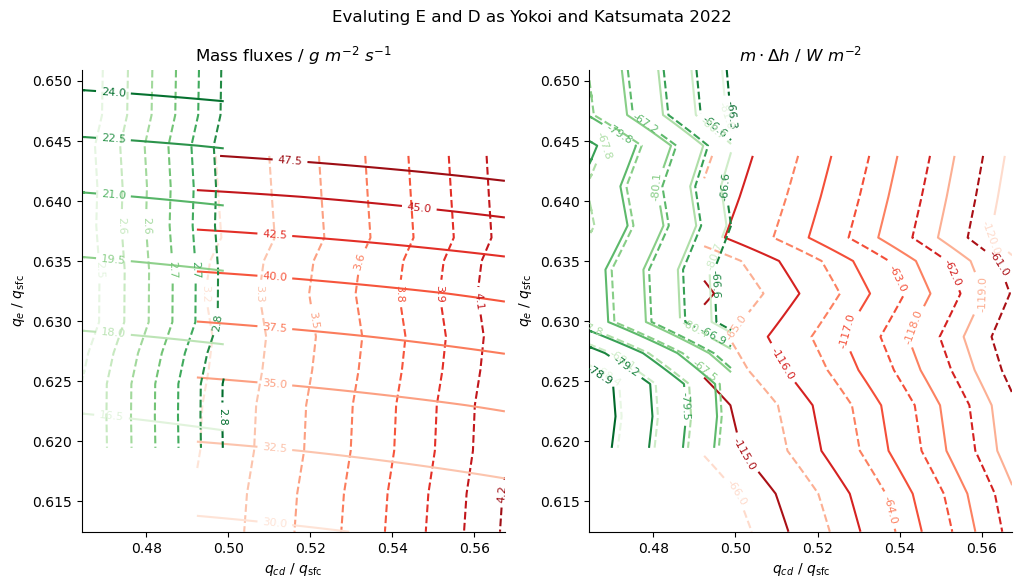

In [46]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Evaluting E and D as Yokoi and Katsumata 2022")

#### report E for values of q_out

xx_eu, yy_eu = np.meshgrid(qSat_out_eu*1e3/q_sfc_eu, q_out_eu*1e3/q_sfc_eu)
xx_or, yy_or = np.meshgrid(qSat_out_or*1e3/q_sfc_or, q_out_or*1e3/q_sfc_or)

c1 = ax[0].contour(xx_eu, yy_eu, mD_eu*1e3, cmap="Reds", linestyles="--")   # , marker="^", facecolors='none', edgecolors="red", label=r"$m_{cd}$ EU")
c2 = ax[0].contour(xx_eu, yy_eu, me_eu*1e3, cmap="Reds")  # , marker="o", facecolors='none', edgecolors="red", label=r"$m_{E}$ EU")

c3 = ax[0].contour(xx_or, yy_or, mD_or*1e3, cmap="Greens", linestyles="--")   # , marker="^", facecolors='none', edgecolors="red", label=r"$m_{cd}$ EU")
c4 = ax[0].contour(xx_or, yy_or, me_or*1e3, cmap="Greens") 

ax[0].set_xlabel(r"$q_{cd}$ / $q_\mathrm{sfc}$")
ax[0].set_ylabel(r"$q_{e}$ / $q_\mathrm{sfc}$")
ax[0].set_title(r"Mass fluxes / $g~m^{-2}~s^{-1}$")
# ax[0].legend()

for c in [c1, c2, c3, c4]:
    plt.clabel(c, inline=True, fontsize=8, fmt='%.1f')


c1 = ax[1].contour(xx_eu, yy_eu, mD_eu*(  cp*(thetaD_eu[np.newaxis, :] - theta_bl_eu.values)    + Lv*(qSat_out_eu[np.newaxis, :] - q_bl_eu.values) ), cmap="Reds", linestyles="--" )
c2 = ax[1].contour(xx_eu, yy_eu, me_eu*(  cp*(theta_out_eu[:, np.newaxis] - theta_bl_eu.values) + Lv*(q_out_eu[:, np.newaxis] - q_bl_eu.values) ), cmap="Reds"   ) 

c3 = ax[1].contour(xx_or, yy_or, mD_or*(  cp*(thetaD_or[np.newaxis, :] - theta_bl_or.values)    + Lv*(qSat_out_or[np.newaxis, :] - q_bl_or.values) ), cmap="Greens", linestyles="--" )
c4 = ax[1].contour(xx_or, yy_or, me_or*(  cp*(theta_out_or[:, np.newaxis] - theta_bl_or.values) + Lv*(q_out_or[:, np.newaxis] - q_bl_or.values) ), cmap="Greens"   ) 

for c in [c1, c2, c3, c4]:
    plt.clabel(c, inline=True, fontsize=8, fmt='%.1f')

ax[1].set_xlabel(r"$q_{cd}$ / $q_\mathrm{sfc}$")
ax[1].set_ylabel(r"$q_{e}$ / $q_\mathrm{sfc}$")
ax[1].set_title(r"$m\cdot \Delta h$ / $W~m^{-2}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



In [59]:
theta_bl_eu.values

array(298.38904, dtype=float32)

#### can we estimate what role advection plays, using differences between each single radiosounding?

In [ ]:

def local_adv(ds, max_hgt):
    heightss = slice(50, max_hgt)
    wspd  = ds.wspd.sel(height=heightss)
    wspd_pair_mean = (wspd + wspd.shift(launch_time=-1)) / 2
    wspd_pair_mean = wspd_pair_mean.isel(launch_time=slice(0, -1)).values

    moist = ds.q.sel(height=heightss)
    th    = ds.theta.sel(height=heightss)

    dt  = (ds.launch_time.diff(dim="launch_time") / np.timedelta64(1,"h"))
    dt = dt.rename("dt")  # give it a name

    dt_hgt = dt.expand_dims(height=wspd.height).transpose("launch_time", "height")

    ## it's actually harder than I was expecting
    ## THIS IS THE TOTAL CHANGE IN TIME
    moist_adv = -wspd_pair_mean*((moist.diff(dim="launch_time")))  / (wspd_pair_mean*dt_hgt)
    th_adv    = -wspd_pair_mean*((th.diff(dim="launch_time")) ) / (wspd_pair_mean*dt_hgt)

    return moist_adv, th_adv




q_adv_eu, th_adv_eu = local_adv(ds_eureca_bco, max_hgt=500)
q_adv_or, th_adv_or = local_adv(ds_orcestra_bco, max_hgt=500)

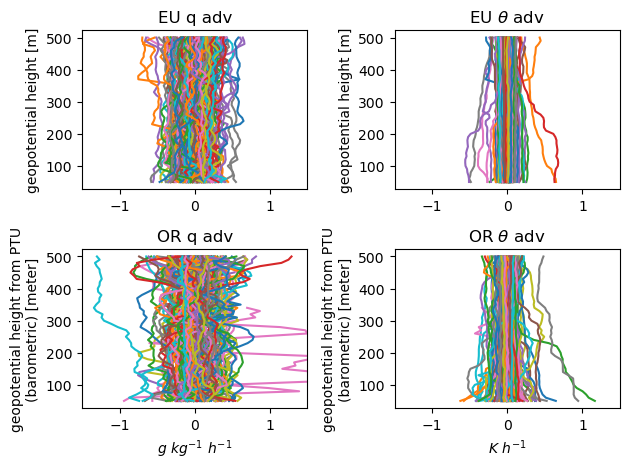

In [49]:
fig, ax = plt.subplots(2,2)
ax = ax.flatten()

(q_adv_eu*1e3).plot.line(ax=ax[0], y="height", add_legend=False)
(q_adv_or*1e3).plot.line(ax=ax[2], y="height", add_legend=False)

ax[0].set_title("EU q adv")
ax[0].set_xlabel("")
ax[2].set_title("OR q adv")
ax[2].set_xlabel(r"$g~kg^{-1}~h^{-1}$")

for x in [ax[0], ax[2]]:
    x.set_xlim(-1.5, 1.5)




th_adv_eu.plot.line(ax=ax[1], y="height", add_legend=False)
th_adv_or.plot.line(ax=ax[3], y="height", add_legend=False)

ax[1].set_title(r"EU $\theta$ adv")
ax[3].set_title(r"OR $\theta$ adv")
ax[1].set_xlabel("")
ax[3].set_xlabel(r"$K~h^{-1}$")

for x in [ax[1], ax[3]]:
    x.set_xlim(-1.5, 1.5)

plt.tight_layout()
plt.show()